<a href="https://colab.research.google.com/github/Youssiffawzy/BrewCrew-Caf-/blob/Seasonal-Sales-Analysis/BrewCrew_Caf%C3%A9_(Seasonal_Sales_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_excel("BrewCrew Café Dataset.xlsx")
df.info()

Saving BrewCrew Café Dataset.xlsx to BrewCrew Café Dataset (3).xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2000 non-null   datetime64[ns]
 1   Time           2000 non-null   object        
 2   Time of Day    2000 non-null   object        
 3   Category       2000 non-null   object        
 4   Channel        2000 non-null   object        
 5   Ad Spend       2000 non-null   float64       
 6   Conversions    2000 non-null   int64         
 7   Quantity Sold  2000 non-null   int64         
 8   Revenue        2000 non-null   float64       
 9   Cost           2000 non-null   float64       
 10  Profit         2000 non-null   float64       
 11  Return         2000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 187.6+ KB


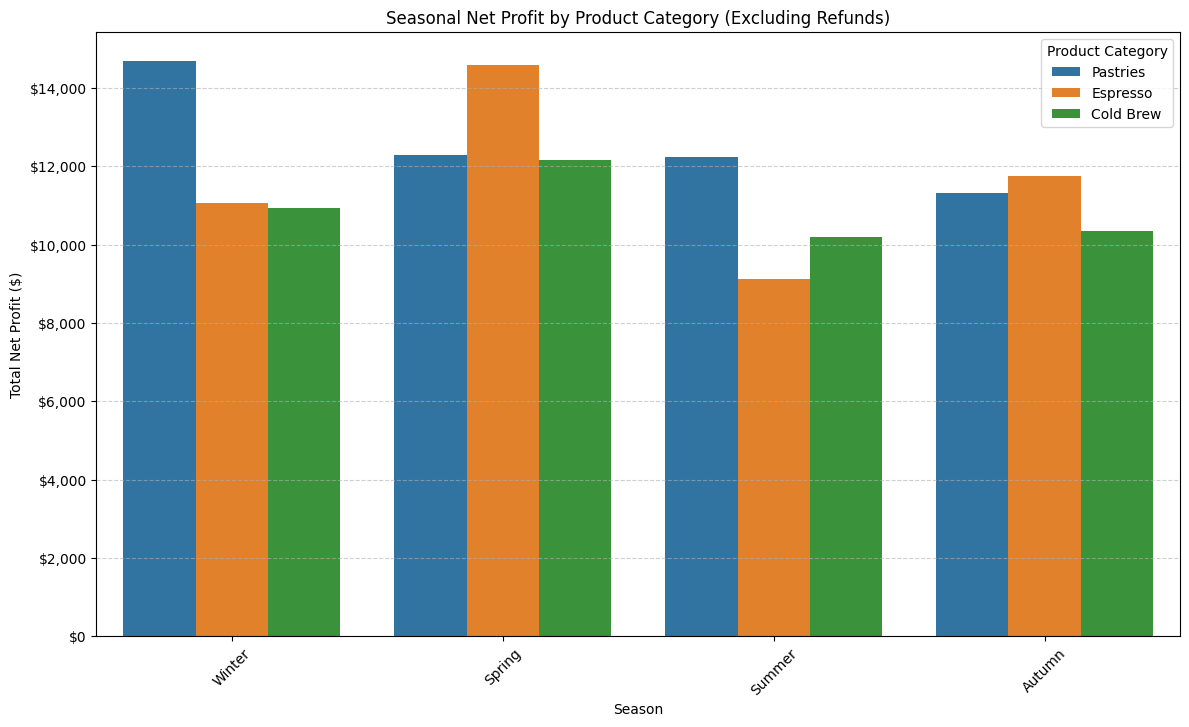

In [13]:
# Filter out refunded transactions
df = df[df['Return'] == 0]

# Convert 'Date' to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Create a 'Season' column
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Date'].apply(get_season)

# Group by Season and Category, and sum Profit
seasonal_profit = df.groupby(['Season', 'Category'])['Profit'].sum().reset_index()

# Define custom season order
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)
seasonal_profit['Season'] = pd.Categorical(seasonal_profit['Season'], categories=season_order, ordered=True)

# Sort the data
seasonal_profit = seasonal_profit.sort_values(by=['Season', 'Profit'], ascending=[True, False])

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 7))
sns.barplot(data=seasonal_profit, x='Season', y='Profit', hue='Category')
plt.title('Seasonal Net Profit by Product Category (Excluding Refunds)')
plt.ylabel('Total Net Profit ($)')
plt.xlabel('Season')
plt.legend(title='Product Category')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()